**Nome**:
      
      Mariana Costa de Mello

      Michelle de Sales Silva

      Nathan Bernardo Novais


#**Predição de Doença Cardíaca Utilizando Regressão Logística e Técnicas de Pré-processamento de Dados**

**Dataset utilizado:** UCI Heart Disease Data

**Link:** https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data?select=heart_disease_uci.csv

Link Github: https://github.com/maricmello/heart-disease-ml

##**1. Importando Bibliotecas**

In [ ]:
import kagglehub
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

##**2. Carregando os dados**

In [ ]:
#Baixando arquivo do kaggle
path = kagglehub.dataset_download("redwankarimsony/heart-disease-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'heart-disease-data' dataset.
Path to dataset files: /kaggle/input/heart-disease-data


In [ ]:
#Definindo o dataframe
df = pd.read_csv(path + "/heart_disease_uci.csv")

print(f"Shape original: {df.shape}")


Shape original: (920, 16)


## **3. Visualizando os dados**

In [ ]:
#Colunas do dataset
df.columns

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

**Dicionário dos dados:**

| Coluna       | Significado                                                                                                                 |
| ------------ | --------------------------------------------------------------------------------------------------------------------------- |
| **id**       | Identificador único de cada paciente.                                                                                       |
| **age**      | Idade do paciente (anos).                                                                                                   |
| **sex**      | Sexo do paciente (`Male` ou `Female`).                                                                                      |
| **dataset**  | Origem do dado (ex.: Cleveland, Hungary, Switzerland, `VA`).                                                          |
| **cp**       | Tipo de dor no peito (categorical):<br> - typical angina<br> - atypical angina<br> - non-anginal<br> - asymptomatic |
| **trestbps** | Pressão arterial em repouso (mmHg).                                                                                         |
| **chol**     | Colesterol sérico total (mg/dl).                                                                                            |
| **fbs**      | Fasting blood sugar > 120 mg/dl (`True`/`False`).                                                                           |
| **restecg**  | Resultados do eletrocardiograma em repouso (categorical):<br> - normal<br> - lv hypertrophy<br> - outros padrões).      |
| **thalch**   | Frequência cardíaca máxima atingida.                                                                                        |
| **exang**    | Angina induzida por exercício (`True`/`False`).                                                                             |
| **oldpeak**  | Depressão do segmento ST induzida pelo exercício em relação ao repouso.                                                     |
| **slope**    | Inclinação do segmento ST no pico do exercício (categorical):<br> - upsloping<br> - flat<br> - downsloping            |
| **ca**       | Número de vasos principais coloridos por fluoroscopia (0–3).                                                                |
| **thal**     | Defeito do miocárdio (categorical):<br> - normal<br> - fixed defect<br> - reversable defect                         |
| **num**      | Diagnóstico de doença cardíaca (0 = sem doença, 1–4 = presença de doença).                                                  |


In [ ]:
#Primeiras 5 linhas
df.head(5)

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [ ]:
#Avaliação descritiva do dataset
df.describe().round(2)

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.00,920.00,861.00,890.00,865.00,858.00,309.00,920.00
mean,460.50,53.51,132.13,199.13,137.55,0.88,0.68,1.00
std,265.73,9.42,19.07,110.78,25.93,1.09,0.94,1.14
min,1.00,28.00,0.00,0.00,60.00,-2.60,0.00,0.00
25%,230.75,47.00,120.00,175.00,120.00,0.00,0.00,0.00
50%,460.50,54.00,130.00,223.00,140.00,0.50,0.00,1.00
75%,690.25,60.00,140.00,268.00,157.00,1.50,1.00,2.00
max,920.00,77.00,200.00,603.00,202.00,6.20,3.00,4.00


In [ ]:
#Verificando nulos
print("\n Valores nulos por coluna:")
nulos = df.isnull().sum()
print(nulos[nulos > 0])


 Valores nulos por coluna:
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
dtype: int64


Há varias colunas com nulos, a estratégia utilizada foi SimpleImputer + Pipeline, que é a abordagem correta para evitar Data Leakage.

In [ ]:
#Verificando as informações da coluna
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


## **4. Criação da variável alvo**

Como o dataset possui num = 0 equivalente a sem doença e num = 1 a 4 como presença de doença, será criado a variável se baseando nisso

In [ ]:
df["target"] = (df["num"] > 0).astype(int)

df["target"].value_counts()

,count
target,
1,509
0,411


## **5. Engenharia de atributos**

Como pacientes mais velhos possuem maior risco cardiovascular foi criado o atributo faixa etária

In [ ]:
#Faixa Etária
df["faixa_idade"] = pd.cut(
    df["age"],
    bins=[0,40,55,70,100],
    labels=["Jovem","Adulto","Meia-idade","Idoso"]
)

Foi criado o atributo colesterol por idade para tentar representar melhor o risco cardiáco

In [ ]:
df["chol_age_ratio"] = (
    df["chol"] / df["age"]
)

## 6. **Análise Exploratória**

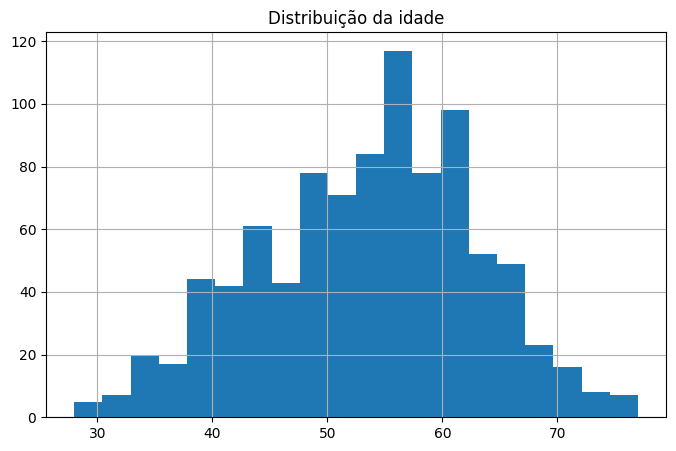

In [ ]:
#Histrograma
df["age"].hist(
    bins=20,
    figsize=(8,5)
)

plt.title("Distribuição da idade")
plt.show()

Com esse gráfico foi possível visualizar:

- Há uma variação das idades entre 28 e 77 anos.
- A maior concentração de pacientes está entre 50 e 65 anos.
- A distribuição é relativamente simétrica, sem grandes assimetrias.

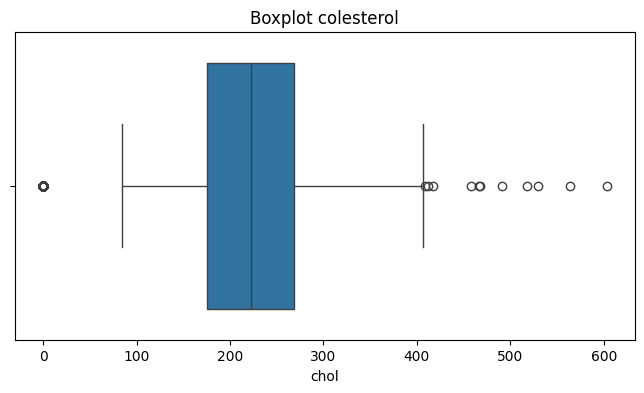

In [ ]:
#Boxplot
plt.figure(figsize=(8,4))

sns.boxplot(
    x=df["chol"]
)

plt.title("Boxplot colesterol")
plt.show()

Com esse gráfico foi possível visualizar:

- A mediana do colesterol está próxima de 225 mg/dL.
- 50% dos pacientes possuem colesterol aproximadamente entre 180 e 270 mg/dL.
- Existem diversos outliers acima de 400 mg/dL.
- Há também um valor próximo de 0 mg/dL (pode ser considerado como valores ausentes pois é impossível biologicamente valor 0 mg/dl)


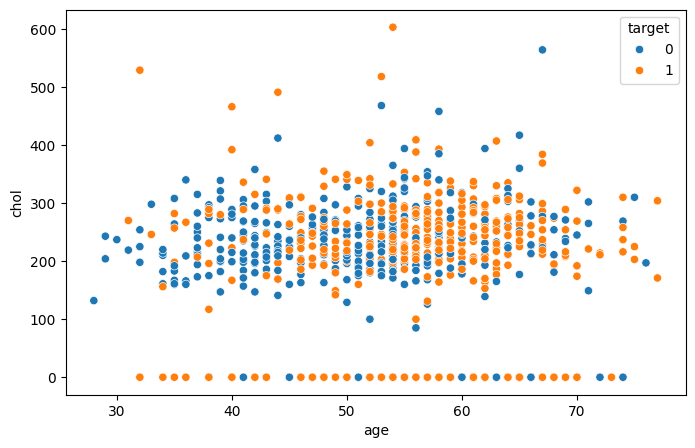

In [ ]:
#Scatterplot
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="age",
    y="chol",
    hue="target"
)

plt.show()

Com esse gráfico foi possível observar:
- Não existe uma tendência linear clara entre idade e colesterol.
- Pessoas jovens podem apresentar colesterol elevado e pessoas idosas podem apresentar colesterol normal.
- Os pacientes com doença (target = 1) aparecem espalhados por praticamente toda a distribuição.

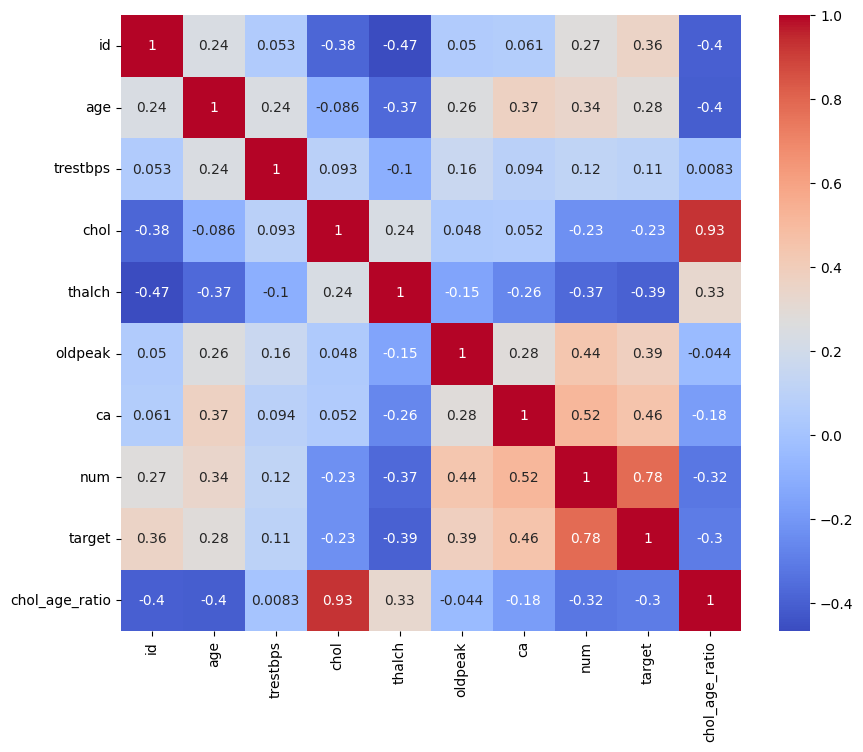

In [ ]:
#Heatmap
plt.figure(figsize=(10,8))

corr = df.select_dtypes(
    include=np.number
).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

O que podemos visualizar com esse gráfico:

- target × num (0.78):
correlação muito forte, como esperado, pois target foi criado a partir da variável num

- ca × target (0.46):
uma das maiores correlações com a variável alvo,
indica que o número de vasos sanguíneos afetados está fortemente relacionado à presença de doença cardíaca

- oldpeak × target (0.39):
correlação positiva moderada, sugere que alterações cardíacas durante esforço físico estão associadas à doença

- thalch × target (-0.39):
correlação negativa moderada, pacientes que atingem maiores frequências cardíacas máximas tendem a apresentar menor incidência da doença

- age × target (0.28):
correlação positiva, pacientes mais velhos possuem maior probabilidade de apresentar doença cardíaca

- chol × target (-0.23):
correlação fraca

## **7. Tratamento de Ouliers (IQR)**

In [ ]:
Q1 = df["chol"].quantile(0.25)
Q3 = df["chol"].quantile(0.75)

IQR = Q3 - Q1

limite_inf = Q1 - 1.5 * IQR
limite_sup = Q3 + 1.5 * IQR

outliers = df[
    (df["chol"] < limite_inf) |
    (df["chol"] > limite_sup)
]

print(len(outliers))

183


Foram identificados outliers na variável colesterol. Como se tratam de medidas médicas reais, optou-se por mantê-los para evitar perda de informação clínica.

## **8. Separação de atributos e alvo**

In [ ]:
X = df.drop(
    columns=["id","num","target"]
)

y = df["target"]

## **9. Identificação de colunas**

In [ ]:
categoricas = X.select_dtypes(
    include=["object","bool","category"]
).columns

numericas = X.select_dtypes(
    include=["int64","float64"]
).columns

print(categoricas)
print(numericas)

Index(['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal',
       'faixa_idade'],
      dtype='object')
Index(['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'chol_age_ratio'], dtype='object')


## **10. Separação Train Test**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

##**11. Pré-Processamento**

In [ ]:
#Numéricas
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

#Categóricas
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numericas),
    ("cat", categorical_transformer, categoricas)
])

## **12. Pipeline**

In [ ]:
pipeline = Pipeline([
    ("preprocessamento", preprocessor),
    ("modelo", LogisticRegression(
        max_iter=5000
    ))
])

## **13. K-Fold Cross Validation**

O K-Fold divide os dados em 5 subconjuntos. Em cada iteração, um subconjunto é utilizado para validação e os demais para treinamento. O processo reduz a dependência de uma única divisão treino/teste.

In [ ]:
kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=kfold,
    scoring="accuracy"
)

print(scores)
print(scores.mean())

[0.80405405 0.81632653 0.84353741 0.83673469 0.80952381]
0.8220353006067291


## **14. GridSearchCV**

In [ ]:
param_grid = {
    "modelo__C":[0.01,0.1,1,10,100],
    "modelo__penalty":["l2"]
}


grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train,y_train)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessamento',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'chol_age_ratio'], dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         Index(['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal',
       'faixa_idade'],
      dtype='object'))])),
                                       ('modelo',
                                        LogisticRegression(max_iter=5000))]),
             n_jobs=-1,
             param_grid={'modelo__C': [0.01, 0.1, 1, 10, 100],
                         'modelo__penalty': ['l2']},
             scoring='accuracy')

In [ ]:
print(grid.best_params_)

{'modelo__C': 1, 'modelo__penalty': 'l2'}


In [ ]:
print(grid.best_score_)

0.8260250045964334


##**15. Predição**

In [ ]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

## **16. Acurracy**

In [ ]:
acc = accuracy_score(
    y_test,
    y_pred
)

print(acc)

0.8478260869565217


## **17. Matriz de Confusão**

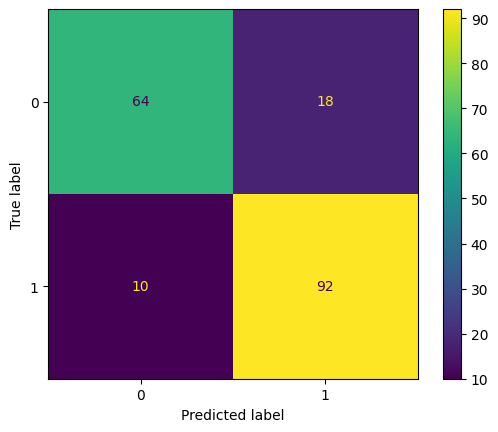

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.show()

A matriz mostra que:

- 64 pacientes saudáveis foram classificados corretamente (Verdadeiros Negativos).
- 92 pacientes com doença cardíaca foram classificados corretamente (Verdadeiros Positivos).
- 18 pacientes saudáveis foram classificados incorretamente como doentes (Falsos Positivos).
- 10 pacientes com doença cardíaca foram classificados incorretamente como saudáveis (Falsos Negativos).


Um aspecto positivo é que o número de falsos negativos (10) foi relativamente baixo. Em aplicações médicas, esse tipo de erro é considerado mais crítico, pois significa que um paciente com doença não seria identificado pelo sistema.

## **18. Report**

In [ ]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.86      0.78      0.82        82
           1       0.84      0.90      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.84      0.84       184
weighted avg       0.85      0.85      0.85       184



Com base nesses resultados, podemos analisar:

Para classe 0 (sem doença), como a precision foi de 0.86, recall de 0.78 e F1-score de 0.82, isso significa que, quando o modelo prevê que um paciente não possui doença cardíaca, ele acerta aproximadamente 86% das vezes. O recall de 78% indica que alguns pacientes saudáveis foram confundidos com pacientes doentes, gerando falsos positivos.

Para classe 1 (doentes), temos precision igual 0.84, recall igual a 0.90 e F1-score igual a 0.87. O recall de 90% é um resultado muito importante, pois demonstra que o modelo consegue identificar corretamente a grande maioria dos pacientes com doença cardíaca. Dos 102 pacientes doentes presentes no conjunto de teste, apenas 10 não foram detectados pelo modelo.

##**Data Leakage**
O vazamento de dados no aprendizado de máquina ou Data Leakage ocorre quando informações do conjunto de teste são utilizadas durante o treinamento do modelo. Resultando em um desempenho artificial elevado e que não representa a capacidade real de generalização.


Com o objetivo de evitar este fenômeno, a divisão dos dados em treino e teste foi realizada antes do treinamento do modelo. Além disso, foi utilizado Pipeline e o ColumnTransformer. Etapas como imputação de valores ausentes, codificação de variáveis categóricas e escalonamento foram ajustadas apenas nos dados de treinamento e posteriormente aplicadas aos dados de teste. A utilização do Pipeline reduz significativamente o risco de vazamento de informações e garante uma avaliação mais confiável do modelo.


## **Conclusão**

Durante a realização do trabalho foram encontradas dificuldades, uma delas foi a presença de valores ausentes em diversas variáveis (algo bem comum em datasets relacionados a medicina). Também foi necessário analisar cuidadosamente as variáveis categóricas para selecionar a estratégia adequada de codificação.

O pré-processamento teve impacto significativo no desempenho do modelo. A utilização de imputação, codificação One-Hot e padronização dos atributos permitiu que a Regressão Logística fosse treinada de forma adequada.

Como trabalhos futuros, poderiam ser avaliados outros algoritmos de classificação, como KNN, Random Forest e XGBoost, além da aplicação de técnicas mais avançadas de engenharia de atributos e seleção de variáveis.

Os valores de precision, recall e F1-score ficaram equilibrados entre as duas classes, indicando que o modelo não apresentou viés significativo para uma das categorias. Além disso, o alto recall da classe "Com Doença" sugere que o modelo possui boa capacidade de identificar pacientes com risco cardiovascular, característica desejável em aplicações relacionadas à saúde.